# Multilayer Perceptron
Nesse notebook, vamos utilizar de um Multilayer Perceptron para fazer duas tarefas, uma de **Regressão** e outra de **Classificação**

In [207]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
import sys
from pathlib import Path
from sklearn.model_selection import train_test_split

root = Path().resolve().parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

# Configurando a placa de vídeo
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print(f"Usando o dispositivo: {device}")

Usando o dispositivo: cuda:0


## Regressão
Nessa tarefa, vamos utilizar do dataset `housing.csv` com o objetivo de prever os preços de casas com base em suas características

In [208]:
data = pd.read_csv(root / "data" / "housing.csv")

In [209]:
t = data["MEDV"]
X = data.drop("MEDV", axis=1)

In [210]:
X_train, X_test, t_train, t_test = train_test_split(X, t, test_size=0.2, random_state=42)

Vou normalizar os meus dados, pois as escalas das colunas estão muito diferentes e isso pode atrapalhar o aprendizado

In [211]:
from sklearn.preprocessing import StandardScaler
    
scaler_X = StandardScaler()
scaler_t = StandardScaler()

# Ajusta e transforma os dados de treino
X_train_scaled = scaler_X.fit_transform(X_train)
t_train_scaled = scaler_t.fit_transform(t_train.values.reshape(-1, 1))

# Transforma os dados de teste
X_test_scaled = scaler_X.transform(X_test)
t_test_scaled = scaler_t.transform(t_test.values.reshape(-1, 1))

# Converta estes novos dados normalizados para tensores!
X_train = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
t_train = torch.tensor(t_train_scaled, dtype=torch.float32).to(device)

X_test = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
t_test = torch.tensor(t_test_scaled, dtype=torch.float32).to(device)

In [212]:
# Criando a Rede Neural
from core import Sequential
from layers import LinearLayer
from functions import Sigmoid
from losses import MeanSquaredError
from optimizers import SGD

mlp = Sequential(
    LinearLayer(X_train.shape[1], 64),
    Sigmoid(),
    LinearLayer(64, 32),
    Sigmoid(),
    LinearLayer(32, 1),
).to(device)

criterium = MeanSquaredError()

optimizer = SGD(mlp.parameters(), learning_rate=0.001)

In [213]:
loss_hist: list[float] = []

for epoch in range(1000):
    optimizer.zero_grad()  # Reset gradients

    # Forward pass
    y_train = mlp.forward(X_train)

    loss = criterium.forward(y_train, t_train)

    loss_hist.append(loss.item())

    # Backward pass
    dloss = criterium.backward()
    mlp.backward(dloss)

    # Update parameters
    optimizer.step()

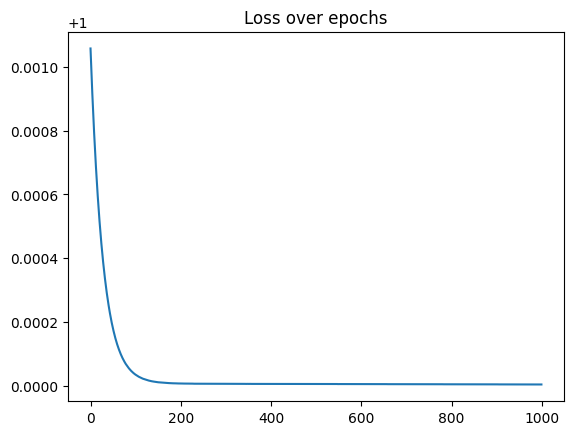

In [214]:
plt.plot(loss_hist)
plt.title("Loss over epochs")
plt.show()

Avaliando o desempenho da rede no conjunto de teste

In [215]:
y_test = mlp.forward(X_test)

In [216]:
loss = criterium.forward(y_test, t_test)

print(f"Test Loss: {loss.item()}")

Test Loss: 0.93131422996521


## Classificação
Nessa tarefa, vamos utilizar um dataset para classificar se as amostras possuem câncer de mama ou não

In [217]:
from sklearn.datasets import load_breast_cancer


data = load_breast_cancer()

X = data.data
t = data.target

In [218]:
X_train, X_test, t_train, t_test = train_test_split(X, t, test_size=0.2, random_state=42)

In [219]:
scaler_X = StandardScaler()

# Ajusta e transforma as features de treino e teste
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Converte as features para tensores PyTorch
X_train = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
X_test = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)

# IMPORTANTE: Os rótulos de classificação (0 e 1) não devem ser normalizados.
# Convertemos os targets originais diretamente para tensores de inteiros (LongTensor)
t_train_tensor = torch.tensor(t_train, dtype=torch.long).to(device)
t_test_tensor = torch.tensor(t_test, dtype=torch.long).to(device)

# Convertemos para One-Hot Encoding de 2 colunas para ser compatível com a perda
t_train_one_hot = torch.nn.functional.one_hot(t_train_tensor, num_classes=2).float().to(device)
t_test_one_hot = torch.nn.functional.one_hot(t_test_tensor, num_classes=2).float().to(device)

In [220]:
from losses import CrossEntropyLogit

# A rede agora tem 2 saídas na última camada para representar os logits de cada classe
mlp = Sequential(
    LinearLayer(X_train.shape[1], 64),
    Sigmoid(),
    LinearLayer(64, 32),
    Sigmoid(),
    LinearLayer(32, 2), # <- Alterado de 1 para 2 saídas
).to(device)

criterium = CrossEntropyLogit()

# Aumentamos o learning rate de 0.001 para 0.05 para o SGD poder convergir com sucesso
optimizer = SGD(mlp.parameters(), learning_rate=0.05)

In [221]:
loss_hist: list[float] = []

for epoch in range(10000):
    optimizer.zero_grad()  # Reseta gradientes

    # Forward pass (predição de logits, shape N x 2)
    y_train = mlp.forward(X_train)

    # Calculamos a perda comparando as predições com os alvos em formato One-Hot
    loss = criterium.forward(y_train, t_train_one_hot)

    loss_hist.append(loss.item())

    # Backward pass
    dloss = criterium.backward()
    mlp.backward(dloss)

    # Atualização de parâmetros
    optimizer.step()

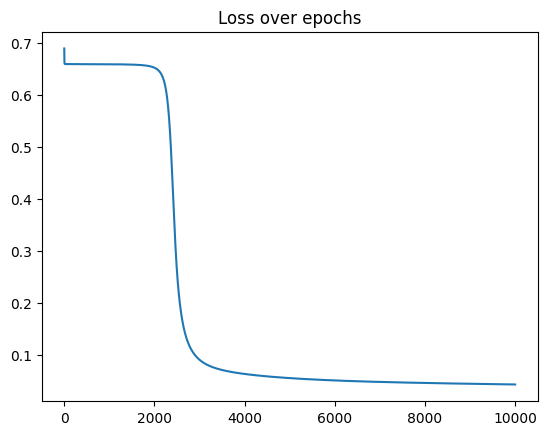

In [222]:
plt.plot(loss_hist)
plt.title("Loss over epochs")
plt.show()

Como nossa rede foi modelada com duas saídas na camada final (`LinearLayer(32, 2)`):
  1. A rede não cospe mais uma probabilidade direta, mas sim um vetor de **logits** de formato `(N, 2)`. A primeira coluna é o score da
classe `0` (não ter câncer) e a segunda é o score da classe `1` (ter câncer).
  2. Para realizar a inferência, aplicamos o método `.argmax(dim=1)`, que escolhe o índice da coluna que obteve o maior score logit
(retornando `0` ou `1`).
  3. Comparamos essa predição final de formato `(N,)` com o tensor original de inteiros do target de teste `t_test_tensor` (também de
formato `(N,)`) para calcular a porcentagem de acertos (acurácia)

In [223]:
def precision(y, t):
    """
    Calcula a precisão do modelo.
    
    Args:
        y (torch.Tensor): Saída do modelo (logits).
        t (torch.Tensor): Rótulos verdadeiros (one-hot).
        
    Returns:
        float: Precisão do modelo.
    """
    # Converte logits em probabilidades usando softmax
    probabilities = torch.softmax(y, dim=1)
    
    # Obtém as classes previstas
    predicted_classes = torch.argmax(probabilities, dim=1)
    
    # Obtém as classes verdadeiras
    true_classes = torch.argmax(t, dim=1)
    
    # Calcula o número de acertos
    correct_predictions = (predicted_classes == true_classes).sum().item()
    
    # Calcula a precisão
    precision_value = correct_predictions / t.size(0)
    
    return precision_value

In [224]:
# 1. Coloca o modelo em modo de avaliação (desativa gradientes e dropouts se houver)
# mlp.eval()

# 2. Executa o forward no conjunto de teste
logits_test = mlp.forward(X_test)

# 3. Obtém o índice da classe com maior pontuação (predição final 0 ou 1)
predictions = logits_test.argmax(dim=1)

# 4. Compara com os rótulos de teste reais (t_test_tensor) e extrai a acurácia
test_accuracy = (predictions == t_test_tensor).float().mean().item()

print(f"Acurácia final no conjunto de teste: {test_accuracy * 100:.2f}%")

Acurácia final no conjunto de teste: 99.12%
